In [1]:
!nvidia-smi

'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from churnguard.data import PROJECT_ROOT

sns.set_theme(style="whitegrid")

train = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "train.parquet")

NUMERIC = ["tenure", "monthly_charges", "total_charges"]
CATEGORICAL = [c for c in train.columns if c not in NUMERIC + ["customer_id", "churned"]]

print(train.shape)
print("Categorical columns:", len(CATEGORICAL))
train.head()

(5634, 21)
Categorical columns: 16


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churned
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,0
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,0
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,0
3,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,0
4,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,0


In [3]:
# Target variable

print(train["churned"].value_counts())
print(f"Churn rate: {train['churned'].mean():.3f}")

churned
0    4139
1    1495
Name: count, dtype: int64
Churn rate: 0.265


In [4]:
# Summary

display(train[NUMERIC].describe().T)
train[NUMERIC].skew()

,count,mean,std,min,25%,50%,75%,max
tenure,5634.0,32.485091,24.568744,0.00,9.0000,29.000,55.0000,72.00
monthly_charges,5634.0,64.929961,30.138105,18.40,35.6625,70.500,90.0000,118.75
total_charges,5626.0,2302.604266,2279.173176,18.85,407.2750,1398.125,3838.6125,8684.80


tenure             0.237369
monthly_charges   -0.224363
total_charges      0.947516
dtype: float64

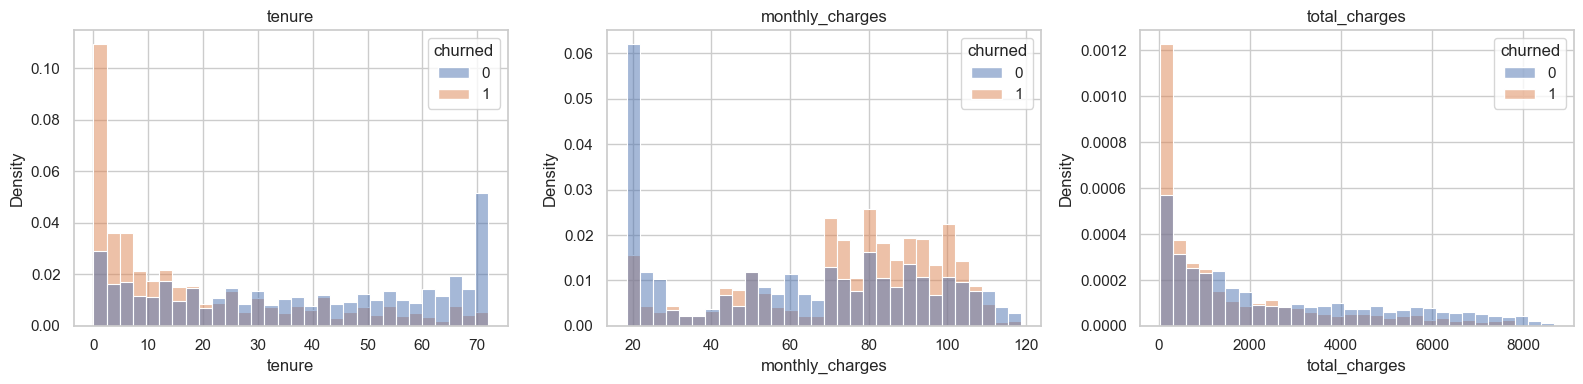

In [5]:
# Numeric distributions, churners vs. non-churners

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, NUMERIC):
    sns.histplot(data=train, x=col, hue="churned", bins=30,
                 stat="density", common_norm=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

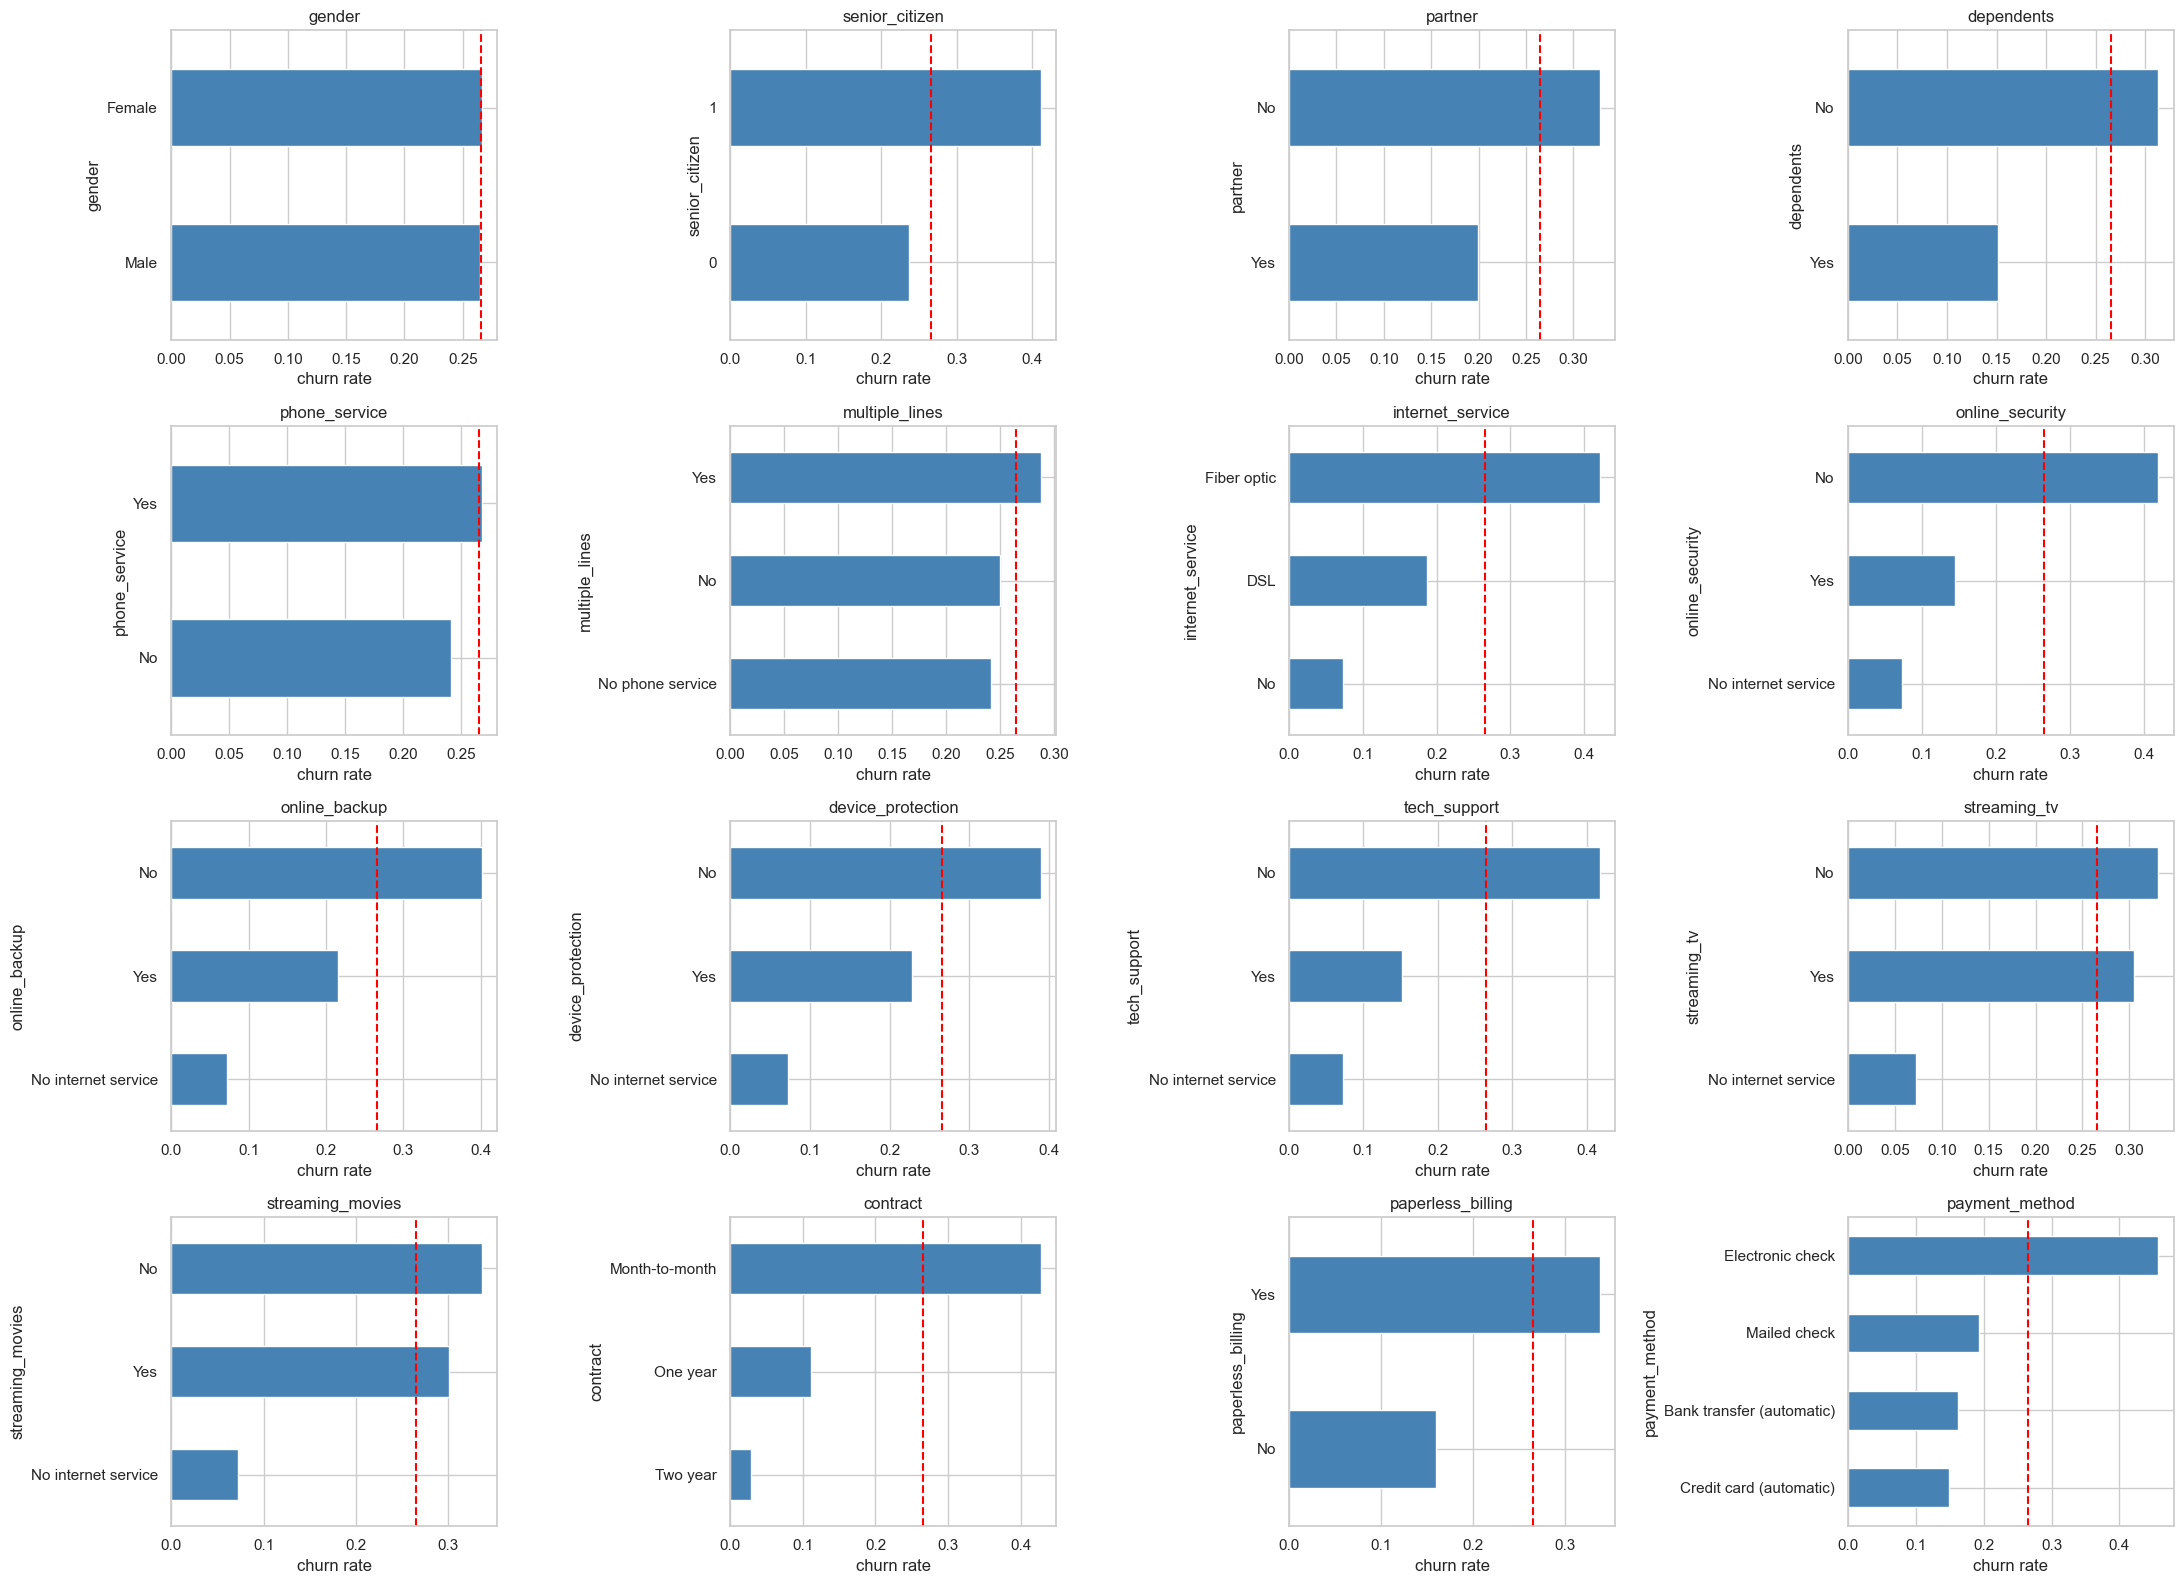

In [6]:
# Churn rate for every categorical feature

fig, axes = plt.subplots(4, 4, figsize=(22, 16))
overall = train["churned"].mean()

for ax, col in zip(axes.flat, CATEGORICAL):
    rates = train.groupby(col)["churned"].mean().sort_values()
    rates.plot.barh(ax=ax, color="steelblue")
    ax.axvline(overall, ls="--", color="red")  # overall churn rate
    ax.set_title(col)
    ax.set_xlabel("churn rate")

plt.tight_layout()
plt.show()

In [7]:
# Statistical tests for categorical features

def cramers_v(table: pd.DataFrame) -> float:
    """Effect size for chi-square: 0 = no association, 1 = perfect."""
    chi2 = stats.chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


rows = []
for col in CATEGORICAL:
    table = pd.crosstab(train[col], train["churned"])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    rows.append({"feature": col, "p_value": p, "cramers_v": cramers_v(table)})

cat_tests = pd.DataFrame(rows).sort_values("cramers_v", ascending=False)
cat_tests.style.format({"p_value": "{:.2e}", "cramers_v": "{:.3f}"})

,feature,p_value,cramers_v
13,contract,1.62e-207,0.411
7,online_security,1.73e-151,0.351
10,tech_support,2.79e-146,0.345
6,internet_service,3.37e-131,0.327
15,payment_method,7.57e-118,0.311
8,online_backup,1.06e-106,0.294
9,device_protection,1.50e-96,0.280
12,streaming_movies,2.13e-66,0.232
11,streaming_tv,1.17e-65,0.230
14,paperless_billing,9.40e-50,0.198


In [8]:
# Statistical tests for numeric features

rows = []
for col in NUMERIC:
    churn = train.loc[train["churned"] == 1, col].dropna()
    stay = train.loc[train["churned"] == 0, col].dropna()
    u, p = stats.mannwhitneyu(churn, stay)
    # Rank-biserial correlation: effect size in [-1, 1].
    # Negative = churners tend to have LOWER values.
    effect = 2 * u / (len(churn) * len(stay)) - 1
    rows.append({
        "feature": col,
        "median_churn": churn.median(),
        "median_stay": stay.median(),
        "p_value": p,
        "effect_size": effect,
    })

pd.DataFrame(rows).style.format({"p_value": "{:.2e}", "effect_size": "{:.3f}"})

,feature,median_churn,median_stay,p_value,effect_size
0,tenure,10.000000,38.000000,1.07e-160,-0.470
1,monthly_charges,79.950000,64.400000,6.32e-46,0.248
2,total_charges,740.300000,1691.900000,1.36e-63,-0.293


In [9]:
# Correlations and redundancy

display(train[NUMERIC].corr(method="spearman").round(3))

approx_total = train["tenure"] * train["monthly_charges"]
print("corr(total_charges, tenure × monthly):",
      round(train["total_charges"].corr(approx_total), 4))

,tenure,monthly_charges,total_charges
tenure,1.000,0.284,0.891
monthly_charges,0.284,1.000,0.642
total_charges,0.891,0.642,1.000


corr(total_charges, tenure × monthly): 0.9996


In [10]:
# The 11 missing values, investigated

missing = train[train["total_charges"].isna()]
print(len(missing), "missing in train")
missing[["tenure", "monthly_charges", "total_charges", "churned"]]

8 missing in train


,tenure,monthly_charges,total_charges,churned
819,0,73.35,NaN,0
1999,0,20.00,NaN,0
2100,0,25.35,NaN,0
4710,0,52.55,NaN,0
5057,0,25.75,NaN,0
5294,0,56.05,NaN,0
5361,0,61.90,NaN,0
5608,0,19.85,NaN,0


In [11]:
# Redundant categories

addons = ["online_security", "online_backup", "device_protection",
          "tech_support", "streaming_tv", "streaming_movies"]

no_internet = train["internet_service"] == "No"
print("All add-ons = 'No internet service' when no internet:",
      (train.loc[no_internet, addons] == "No internet service").all().all())
print("'No internet service' appears for internet customers:",
      (train.loc[~no_internet, addons] == "No internet service").any().any())

pd.crosstab(train["phone_service"], train["multiple_lines"])

All add-ons = 'No internet service' when no internet: True
'No internet service' appears for internet customers: False


multiple_lines,No,No phone service,Yes
phone_service,,,
No,0,559,0
Yes,2685,0,2390


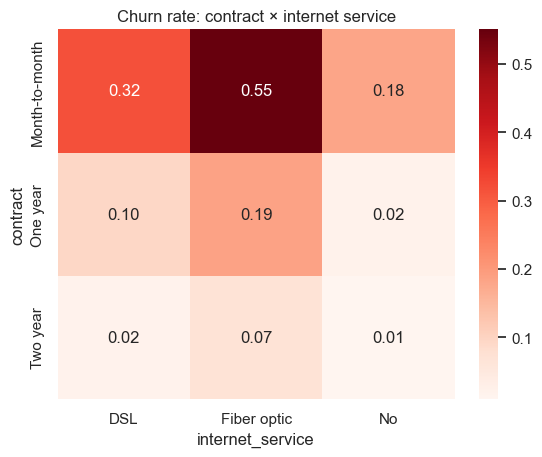

In [12]:
# Interactions between features

pivot = train.pivot_table(index="contract", columns="internet_service",
                          values="churned", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds")
plt.title("Churn rate: contract × internet service")
plt.show()